In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
import sys
import os
 
# Path to your Who&When JSON file — edit this.
DATASET_DIR = "./ww"
SUBSET = "hand-crafted"
 
# Model names used in the evaluation plan.
MODEL_LLAMA = "/data/hoang/resources/models/meta-llama/Llama-3.1-8B-Instruct"
MODEL_QWEN  = "/data/hoang/resources/models/Qwen/Qwen3-8B" 

# Which model to load in this session.
MODEL_NAME = MODEL_LLAMA
 
DEVICE = "1"   # "cpu" for a CPU-only sanity pass (slow)

In [2]:
from core.data import load_dataset, build_context, select_context
from utils.graph import get_dependency_dict, derive_llm_inputs
import math

from transformers import PreTrainedModel, PreTrainedTokenizer
from torch import Tensor
from core.gradnorm import _ntp_loss


trajectories  = load_dataset(DATASET_DIR, subset=SUBSET)
traj = trajectories[11]
len(traj.history)
deps = get_dependency_dict(derive_llm_inputs(traj.history))
# traj.history

In [4]:
[traj.mistake_agent for traj in trajectories]

['WebSurfer',
 'WebSurfer',
 'WebSurfer',
 'WebSurfer',
 'WebSurfer',
 'Orchestrator',
 'WebSurfer',
 'WebSurfer',
 'Orchestrator',
 'Orchestrator',
 'WebSurfer',
 'Assistant',
 'WebSurfer',
 'Orchestrator',
 'WebSurfer',
 'Orchestrator',
 'WebSurfer',
 'WebSurfer',
 'Orchestrator',
 'WebSurfer',
 'WebSurfer',
 'FileSurfer',
 'WebSurfer',
 'Orchestrator',
 'Orchestrator',
 'FileSurfer',
 'WebSurfer',
 'WebSurfer',
 'WebSurfer',
 'Assistant',
 'Orchestrator',
 'Orchestrator',
 'WebSurfer',
 'WebSurfer',
 'WebSurfer',
 'Orchestrator',
 'WebSurfer',
 'Orchestrator',
 'Orchestrator',
 'WebSurfer',
 'WebSurfer',
 'Orchestrator',
 'Assistant',
 'WebSurfer',
 'Orchestrator',
 'WebSurfer',
 'Orchestrator',
 'WebSurfer',
 'WebSurfer',
 'WebSurfer',
 'FileSurfer',
 'WebSurfer',
 'Assistant',
 'WebSurfer',
 'Orchestrator',
 'WebSurfer',
 'WebSurfer',
 'Orchestrator']

In [3]:
deps

{0: [],
 1: [0],
 2: [0, 1],
 3: [2],
 4: [0, 1, 3],
 5: [0, 1, 3, 4],
 6: [5],
 7: [5],
 8: [0, 1, 3, 4, 6],
 9: [0, 1, 3, 4, 6, 8],
 10: [9],
 11: [9],
 12: [0, 1, 3, 4, 6, 8, 10],
 13: [0, 1, 3, 4, 6, 8, 10, 12],
 14: [13],
 15: [13],
 16: [0, 1, 3, 4, 6, 8, 10, 12, 14],
 17: [0, 1, 3, 4, 6, 8, 10, 12, 14, 16],
 18: [0, 1, 3, 4, 6, 8, 10, 12, 14, 16],
 19: [0, 1, 3, 4, 6, 8, 10, 12, 14, 16]}

In [4]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

print(f"\nLoading tokeniser: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# print(f"Loading model ({MODEL_NAME}) → {DEVICE}")
# model = AutoModelForCausalLM.from_pretrained(
#     MODEL_NAME,
#     torch_dtype  = torch.bfloat16,
#     device_map   = {"": int(DEVICE)},
# )
# model.eval()
# n_params = sum(p.numel() for p in model.parameters())

# print(f"  {n_params / 1e9:.2f}B parameters loaded.\n")


Loading tokeniser: /data/hoang/resources/models/meta-llama/Llama-3.1-8B-Instruct


In [6]:
messages = [
  {"role": "system", "content": "You are a bot that responds to weather queries."},
  {"role": "user", "content": "Hey, what's the temperature in Paris right now?"}
]

inputs = tokenizer.apply_chat_template(messages, add_generation_prompt=True)
inputs

{'input_ids': [128000, 128006, 9125, 128007, 271, 38766, 1303, 33025, 2696, 25, 6790, 220, 2366, 18, 198, 15724, 2696, 25, 220, 1627, 10263, 220, 2366, 19, 271, 2675, 527, 264, 11164, 430, 31680, 311, 9282, 20126, 13, 128009, 128006, 882, 128007, 271, 19182, 11, 1148, 596, 279, 9499, 304, 12366, 1314, 1457, 30, 128009, 128006, 78191, 128007, 271], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

In [5]:
def pad_encoded(encoded: dict[Tensor, int], max_tokens=4096):
    padded = tokenizer.pad(
        [{"input_ids": ids} for ids in encoded["input_ids"]],
        return_tensors="pt",
        padding_side="left",
        padding="max_length",
        max_length=max_tokens
    )
    padded_ids, attention_mask = padded["input_ids"], padded["attention_mask"]
    num_padded = int(attention_mask.shape[1] - attention_mask.sum(dim=1))
    padded_ctx_len = encoded["ctx_len"] + num_padded
    return {
        "input_ids": padded_ids, 
        "attention_mask": attention_mask, 
        "ctx_len": padded_ctx_len
    }

In [15]:
# ── Clean up memory ─────────────────────────────────────────────
def memory_accounting():
    device = f"cuda:{DEVICE}"
    before_mb = torch.cuda.memory_reserved(device) / 1e6
    torch.cuda.empty_cache()
    after_mb = torch.cuda.memory_reserved(device) / 1e6
    print(f"[{device}] reserved: {before_mb:.1f} MB → {after_mb:.1f} MB "
          f"(freed {before_mb - after_mb:.1f} MB)")
    print(f"[{device}] allocated: {torch.cuda.memory_allocated(device) / 1e6:.1f} MB")


## Standard Gradnorm

In [8]:
def gradnorm_standard(
    model:          PreTrainedModel,
    input_ids:      Tensor,
    attention_mask: Tensor,
    ctx_len:        int,
    normalize:      bool = True,
) -> dict:
    # ── Compute gradients ────────────────────────────────────────────
    logits = model(
        input_ids, 
        attention_mask, 
        use_cache=False
    ).logits
    loss   = _ntp_loss(logits, input_ids, ctx_len)
    loss.backward()

    # ── Compute score ────────────────────────────────────────────────
    target_weights = list(model.model.layers) + [model.lm_head]
    n_layers = len(model.model.layers)
    module_names = [f"layer_{i}" for i in range(n_layers)] + ["lm_head"]

    statistics = {}
    for name, module in zip(module_names, target_weights):
        n_params = sum(p.numel() for p in module.parameters())
        l1_norm  = sum(p.grad.detach().abs().sum().item() for p in module.parameters())
        l2_norm  = math.sqrt(
            sum(p.grad.detach().norm(2).item() ** 2 for p in module.parameters())
        )
        if normalize:
            l1_norm /= n_params
            l2_norm /= n_params

        statistics[name] = {
            "l1_norm": l1_norm,
            "l2_norm": l2_norm,
        }

    # ── Cleanup ──────────────────────────────────────────────────────
    for p in model.parameters():
        p.grad = None
    memory_accounting()
    
    return statistics

In [ ]:

trajectories  = load_dataset(DATASET_DIR, subset=SUBSET)
traj = trajectories[11]
context_builder = build_context
MAX_TOKENS = 4096

tests = []

for step_idx in range(len(traj.history)):
    # ── Tokenise ────────────────────────────────────────────────────
    encoded   = context_builder(
        traj.history, 
        step_idx, 
        tokenizer,
        max_tokens=MAX_TOKENS
    )
    # encoded = pad_encoded(encoded)

    input_ids = encoded["input_ids"].to(f"cuda:{DEVICE}")   # (1, seq_len)
    attention_mask = encoded.get("attention_mask", None)
    ctx_len   = encoded["ctx_len"]
    seq_len   = input_ids.shape[1]

    print(f"seq_len: {seq_len}, ctx_len: {ctx_len}")

    statistics = gradnorm_standard(
        model, input_ids, attention_mask, ctx_len
    )
    if isinstance(attention_mask, Tensor):
        attention_mask = attention_mask.tolist()
    elif attention_mask is None:
        attention_mask = None
    else:
        raise NotImplementedError()
    
    out = {
        "metadata": {
            "filename": traj.filename,
            "step_idx": step_idx,
            "input_ids": input_ids.tolist(),
            "attention_mask": attention_mask,
            "ctx_len": ctx_len,
        },
        "statistics": statistics
    }
    tests.append(out)

seq_len: 76, ctx_len: 8
[cuda:1] CUDA allocated : 8085.1 MB
[cuda:1] CUDA reserved  : 8134.9 MB
seq_len: 800, ctx_len: 70
[cuda:1] CUDA allocated : 8305.3 MB
[cuda:1] CUDA reserved  : 8350.9 MB
seq_len: 1091, ctx_len: 794
[cuda:1] CUDA allocated : 8393.5 MB
[cuda:1] CUDA reserved  : 8443.1 MB
seq_len: 385, ctx_len: 299
[cuda:1] CUDA allocated : 8179.4 MB
[cuda:1] CUDA reserved  : 8227.1 MB
seq_len: 2154, ctx_len: 874
[cuda:1] CUDA allocated : 8716.6 MB
[cuda:1] CUDA reserved  : 8766.1 MB
seq_len: 2469, ctx_len: 2148
[cuda:1] CUDA allocated : 8812.8 MB
[cuda:1] CUDA reserved  : 8860.5 MB
seq_len: 408, ctx_len: 323
[cuda:1] CUDA allocated : 8186.0 MB
[cuda:1] CUDA reserved  : 8235.5 MB
seq_len: 347, ctx_len: 323
[cuda:1] CUDA allocated : 8167.4 MB
[cuda:1] CUDA reserved  : 8216.6 MB
seq_len: 3367, ctx_len: 2227
[cuda:1] CUDA allocated : 9085.4 MB
[cuda:1] CUDA reserved  : 9133.1 MB
seq_len: 3684, ctx_len: 3361
[cuda:1] CUDA allocated : 9181.9 MB
[cuda:1] CUDA reserved  : 9229.6 MB
seq_le

In [16]:
memory_accounting()

[cuda:1] reserved: 26831.0 MB → 16502.5 MB (freed 10328.5 MB)
[cuda:1] allocated: 16398.6 MB


In [ ]:
import json
os.makedirs("tests", exist_ok=True)
with open("tests/standard-unpadded.json", "w") as f:
    json.dump(tests, f, indent=4)

In [ ]:
tests1 = json.load(open("tests/standard-padded.json"))
tests2 = json.load(open("tests/standard-unpadded.json"))

In [ ]:
layer_names = [key for key in tests1[0]["statistics"]]

name = layer_names[-4]
stat1 = tests1[0]["statistics"][name]
stat2 = tests2[0]["statistics"][name]
name, stat1, stat2

('layer_33',
 {'l1_norm': 0.0004390267500165658, 'l2_norm': 1.485981021025087e-07},
 {'l1_norm': 0.00043918508093454827, 'l2_norm': 1.4851277199824687e-07})

In [ ]:
print("Well padded and unpadded are roughly the same.")
print("They are ready to be testcases for optimization")

Well padded and unpadded are roughly the same.
They are ready to be testcases for optimization


## Memory optimization

In [7]:
memory_accounting()

[cuda:1] allocated: 16381.5 MB → 16381.5 MB (freed 0.0 MB)
[cuda:1] reserved: 16385.0 MB


In [8]:
import math
import math
import torch
from torch import Tensor
from transformers import PreTrainedModel

def gradnorm_hooked(
    model:          PreTrainedModel,
    input_ids:      Tensor,
    attention_mask: Tensor,
    ctx_len:        int,
    normalize:      bool = True,
) -> dict:
    # ── 1. Fix ACTIVATION memory ─────────────────────────────────────
    # HF silently ignores gradient checkpointing if model is in eval mode!
    was_training = model.training
    model.train()
    
    # Ensure inputs require grad so checkpointing triggers correctly
    if hasattr(model, "enable_input_require_grads"):
        model.enable_input_require_grads()
        
    model.gradient_checkpointing_enable()

    # ── Build module → name mapping ──────────────────────────────────
    target_modules = {module: name for name, module in zip(
        [f"layer_{i}" for i in range(len(model.model.layers))] + ["lm_head"],
        list(model.model.layers) + [model.lm_head],
    )}

    # ── 2. Fix GRADIENT memory via Post-Accumulate Hooks ─────────────
    statistics = {}
    handles = []
    hooked_params = set() # Prevents double-counting tied weights (e.g. Qwen embeddings)
    
    # Pre-allocate stats on GPU to prevent CPU-GPU sync bottlenecks!
    device = next(model.parameters()).device

    for module, name in target_modules.items():
        statistics[name] = {
            "l1_norm": torch.tensor(0.0, device=device, dtype=torch.float64), 
            "l2_norm_sq": torch.tensor(0.0, device=device, dtype=torch.float64), 
            "n_params": 0
        }
        
        for p in module.parameters():
            if not p.requires_grad or p in hooked_params:
                continue
            hooked_params.add(p)
            
            entry = statistics[name]
            entry["n_params"] += p.numel()

            def make_stat_hook(entry_dict):
                # PyTorch 2.1+ post-accumulate hook receives the parameter itself
                def hook(param):
                    if param.grad is not None:
                        with torch.no_grad():
                            # Cast to float32/64 to prevent bf16 overflow when squaring
                            grad_f32 = param.grad.float()
                            entry_dict["l1_norm"]    += grad_f32.abs().sum().double()
                            entry_dict["l2_norm_sq"] += grad_f32.square().sum().double()
                        
                        # ✨ IMMEDIATELY free the gradient memory! ✨
                        param.grad = None
                return hook

            h = p.register_post_accumulate_grad_hook(make_stat_hook(entry))
            handles.append(h)

    # ── 3. Catch untracked parameters (embeddings, layernorm) ────────
    # So they don't silently leak VRAM
    def clear_hook(param):
        param.grad = None

    for p in model.parameters():
        if p.requires_grad and p not in hooked_params:
            h = p.register_post_accumulate_grad_hook(clear_hook)
            handles.append(h)
            hooked_params.add(p)

    # ── Forward + backward ───────────────────────────────────────────
    model.zero_grad(set_to_none=True)
    
    logits = model(
        input_ids, attention_mask, use_cache=False,
    ).logits
    
    loss = _ntp_loss(logits, input_ids, ctx_len)
    
    # As backward runs, gradients are instantiated, recorded, and instantly destroyed!
    loss.backward()

    # ── Cleanup ──────────────────────────────────────────────────────
    for h in handles:
        h.remove()
        
    model.gradient_checkpointing_disable()
    if not was_training:
        model.eval()

    # ── 4. Pull metrics to CPU exactly ONCE ──────────────────────────
    for name, stats in statistics.items():
        n_params = stats.pop("n_params")
        
        l1_val = stats.pop("l1_norm").item()
        l2_val = math.sqrt(stats.pop("l2_norm_sq").item())
        
        if normalize and n_params > 0:
            l1_val /= n_params
            l2_val /= n_params
            
        stats["l1_norm"] = l1_val
        stats["l2_norm"] = l2_val

    # Double check no stray gradients remain
    model.zero_grad(set_to_none=True)

    return statistics

In [17]:
trajectories  = load_dataset(DATASET_DIR, subset=SUBSET)
traj_idx = 11
step_idx = 15
traj = trajectories[traj_idx]
context_builder = build_context
MAX_TOKENS = 8192

# ── Tokenise ────────────────────────────────────────────────────
encoded   = context_builder(
    traj.history, 
    step_idx, 
    tokenizer,
    max_tokens=MAX_TOKENS
)
encoded = pad_encoded(encoded, max_tokens=MAX_TOKENS)

input_ids = encoded["input_ids"].to(f"cuda:{DEVICE}")   # (1, seq_len)
attention_mask = encoded.get("attention_mask", None)
ctx_len   = encoded["ctx_len"]
seq_len   = input_ids.shape[1]
print(f"seq_len: {seq_len}, ctx_len: {ctx_len}")

statistics = gradnorm_hooked(
    model, input_ids, attention_mask, ctx_len
)

seq_len: 8192, ctx_len: 8085


In [14]:
torch.cuda.memory_reserved("cuda:1") / 1e6

26830.962688

In [10]:
memory_accounting()

[cuda:1] allocated: 16398.6 MB → 16398.6 MB (freed 0.0 MB)
[cuda:1] reserved: 16502.5 MB


In [ ]:
for p in model.parameters():
    # p.grad = None
    if p.grad is not None: print(p.grad)

In [ ]:
statistics = gradnorm_standard(
    model, input_ids, attention_mask, ctx_len
)

In [26]:
memory_accounting()
for p in model.parameters():
    p.grad = None

[cuda:1] allocated: 8062.0 MB → 8062.0 MB (freed 0.0 MB)
[cuda:1] reserved: 8099.2 MB


In [19]:

trajectories  = load_dataset(DATASET_DIR, subset=SUBSET)
traj = trajectories[11]
context_builder = build_context
MAX_TOKENS = 4096

tests = []

for step_idx in range(len(traj.history)):
    # ── Tokenise ────────────────────────────────────────────────────
    encoded   = context_builder(
        traj.history, 
        step_idx, 
        tokenizer,
        max_tokens=MAX_TOKENS
    )
    encoded = pad_encoded(encoded)

    input_ids = encoded["input_ids"].to(f"cuda:{DEVICE}")   # (1, seq_len)
    attention_mask = encoded.get("attention_mask", None)
    ctx_len   = encoded["ctx_len"]
    seq_len   = input_ids.shape[1]

    print(f"seq_len: {seq_len}, ctx_len: {ctx_len}")

    statistics = gradnorm_hooked(
        model, input_ids, attention_mask, ctx_len
    )
    if isinstance(attention_mask, Tensor):
        attention_mask = attention_mask.tolist()
    elif attention_mask is None:
        attention_mask = None
    else:
        raise NotImplementedError()
    
    out = {
        "metadata": {
            "filename": traj.filename,
            "step_idx": step_idx,
            "input_ids": input_ids.tolist(),
            "attention_mask": attention_mask,
            "ctx_len": ctx_len,
        },
        "statistics": statistics
    }
    tests.append(out)

seq_len: 4096, ctx_len: 4028
seq_len: 4096, ctx_len: 3366
seq_len: 4096, ctx_len: 3799
seq_len: 4096, ctx_len: 4010
seq_len: 4096, ctx_len: 2816
seq_len: 4096, ctx_len: 3775
seq_len: 4096, ctx_len: 4011
seq_len: 4096, ctx_len: 4072
seq_len: 4096, ctx_len: 2956
seq_len: 4096, ctx_len: 3773
seq_len: 4096, ctx_len: 4031
seq_len: 4096, ctx_len: 4071
seq_len: 4096, ctx_len: 2544
seq_len: 4096, ctx_len: 3838
seq_len: 4096, ctx_len: 4026
seq_len: 4096, ctx_len: 3989
seq_len: 4096, ctx_len: 3765
seq_len: 4096, ctx_len: 3865
seq_len: 4096, ctx_len: 4073
seq_len: 4096, ctx_len: 4042


In [ ]:
import json
tests_padded = json.load(open("tests/standard-padded.json"))

In [25]:
layer_names = [key for key in tests_padded[0]["statistics"]]

name = layer_names[-15]
stat1 = tests[0]["statistics"][name]
stat2 = tests_padded[0]["statistics"][name]
name, stat1, stat2

('layer_22',
 {'l1_norm': 0.0007828110825263432, 'l2_norm': 2.586599180327348e-07},
 {'l1_norm': 0.0007833052754175692, 'l2_norm': 2.590100212218981e-07})

In [ ]:
for p in model.parameters():
    p.grad = None
memory_accounting()

[cuda:1] allocated: 40033.3 MB → 40033.3 MB (freed 0.0 MB)
[cuda:1] reserved: 45113.9 MB


## Statistics

In [7]:
import pandas as pd
llama = pd.read_csv("results/gradnorm_llama.tsv", sep="\t")

In [ ]:
import json
import numpy as np
import pandas as pd
from pathlib import Path

RESULTS_DIR = Path("outputs/qwen3-8b/grad-norm/hand-crafted")

results = [json.loads(f.read_text()) for f in sorted(RESULTS_DIR.glob("*.json"))]

# ── discover layers ──────────────────────────────────────────────────────────
all_layers = []
seen = set()
for r in results:
    for log in r["logs"]:
        for k in log.get("l1_norm", {}):
            if k not in seen:
                seen.add(k); all_layers.append(k)

# sort: layer_N numerically, then rest (e.g. lm_head)
all_layers = sorted(
    [l for l in all_layers if l.startswith("layer_") and l.split("_")[1].isdigit()],
    key=lambda x: int(x.split("_")[1])
) + [l for l in all_layers if not (l.startswith("layer_") and l.split("_")[1].isdigit())]

# ── compute per-trajectory stats for each (layer, norm) ─────────────────────
rows = []
for layer in all_layers:
    for norm in ("l1", "l2"):
        z_scores, ranges, margins = [], [], []
        for r in results:
            t_star = int(r["metadata"]["mistake_step"])
            scores = {
                int(log["step_idx"]): log.get(f"{norm}_norm", {}).get(layer)
                for log in r["logs"]
            }
            scores = {k: v for k, v in scores.items() if v is not None}
            if t_star not in scores or len(scores) < 2:
                continue

            vals = np.array(list(scores.values()))
            mu, sigma = vals.mean(), vals.std()

            z  = (scores[t_star] - mu) / sigma if sigma > 0 else 0.0
            rng = (vals.max() - vals.min()) 
            others = [v for k, v in scores.items() if k != t_star]
            margin = (scores[t_star] - max(others))

            z_scores.append(z); ranges.append(rng); margins.append(margin)

        rows.append({
            "layer": layer,
            "norm":  norm.upper(),
            "mean_z":      f"{np.mean(z_scores):.2f}",
            "mean_range":  f"{np.mean(ranges):.2e}",
            "mean_margin": f"{np.mean(margins):.2e}",
        })

# ── format: combined L1/L2 rows ──────────────────────────────────────────────
table_rows = []
for layer in all_layers:
    l1 = next(r for r in rows if r["layer"] == layer and r["norm"] == "L1")
    l2 = next(r for r in rows if r["layer"] == layer and r["norm"] == "L2")
    table_rows.append({
        "layer": layer,
        "mean_z":      f"{l1['mean_z']} / {l2['mean_z']}",
        "mean_range":  f"{l1['mean_range']} / {l2['mean_range']}",
        "mean_margin": f"{l1['mean_margin']} / {l2['mean_margin']}",
    })

print(pd.DataFrame(table_rows).set_index("layer").to_string())

                 mean_z           mean_range            mean_margin
layer                                                              
layer_0   -0.63 / -0.62  7.41e-04 / 1.91e-07  -6.83e-04 / -1.76e-07
layer_1   -0.61 / -0.59  3.41e-04 / 1.60e-07  -3.14e-04 / -1.46e-07
layer_2   -0.61 / -0.60  3.87e-04 / 1.88e-07  -3.56e-04 / -1.72e-07
layer_3   -0.61 / -0.60  5.43e-04 / 2.04e-07  -5.00e-04 / -1.87e-07
layer_4   -0.61 / -0.59  8.09e-04 / 2.08e-07  -7.46e-04 / -1.91e-07
layer_5   -0.61 / -0.60  1.00e-03 / 2.01e-07  -9.23e-04 / -1.84e-07
layer_6   -0.61 / -0.62  1.12e-03 / 7.43e-07  -1.04e-03 / -6.81e-07
layer_7   -0.60 / -0.59  1.13e-03 / 2.30e-07  -1.04e-03 / -2.11e-07
layer_8   -0.61 / -0.59  1.27e-03 / 1.84e-07  -1.17e-03 / -1.69e-07
layer_9   -0.60 / -0.59  1.37e-03 / 2.03e-07  -1.26e-03 / -1.86e-07
layer_10  -0.60 / -0.59  1.46e-03 / 2.24e-07  -1.35e-03 / -2.05e-07
layer_11  -0.60 / -0.59  1.43e-03 / 2.04e-07  -1.31e-03 / -1.87e-07
layer_12  -0.60 / -0.59  1.49e-03 / 2.17e-07  -1

In [ ]:
from collections import Counter
from pathlib import Path
import json
import pandas as pd

RESULTS_DIR = Path("outputs/qwen3-8b/grad-norm/hand-crafted")
LAYER = "lm_head"
NORM  = "l1_norm"
results = [json.loads(f.read_text()) for f in sorted(RESULTS_DIR.glob("*.json"))]

predicted = Counter()
for r in results:
    step_agents = {int(s["step_idx"]): s["role"] for s in r["steps"]}
    scores = {
        int(log["step_idx"]): log.get(NORM, {}).get(LAYER)
        for log in r["logs"]
        if step_agents.get(int(log["step_idx"]), "").lower() != "human"
    }
    if not scores:
        continue
    top_step = min(scores, key=lambda k: scores[k])
    agentx = step_agents.get(top_step, "unknown")
    if "orchestrator" in agentx.lower():
        agentx = "Orchestrator"
    predicted[agentx] += 1

true_agents = Counter(r["metadata"]["mistake_agent"] for r in results)
pd.DataFrame({
    "predicted_top1": predicted,
    "true_mistake":   true_agents,
}).fillna(0).astype(int).sort_values("predicted_top1", ascending=False)

,predicted_top1,true_mistake
WebSurfer,39,33
Orchestrator,15,18
FileSurfer,4,3
Assistant,0,4


In [ ]:
"""
RESULTS_DIR = Path("outputs/qwen3-8b/grad-norm/hand-crafted")
mistake_scores = []
normal_scores =  []

for each file in the RESULTS_DIR:
    data = load(file)
    scores = data["scores"]
    mistake_scores.append(scores[mistake_step])
    normal_scores.append(scores[normal_steps])

plot_distribution(mistake_scores, normal_scores)
"""

In [7]:
# ── Distribution of Mistake vs Normal GradNorm Scores ────────────────────────
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.stats import gaussian_kde
import math

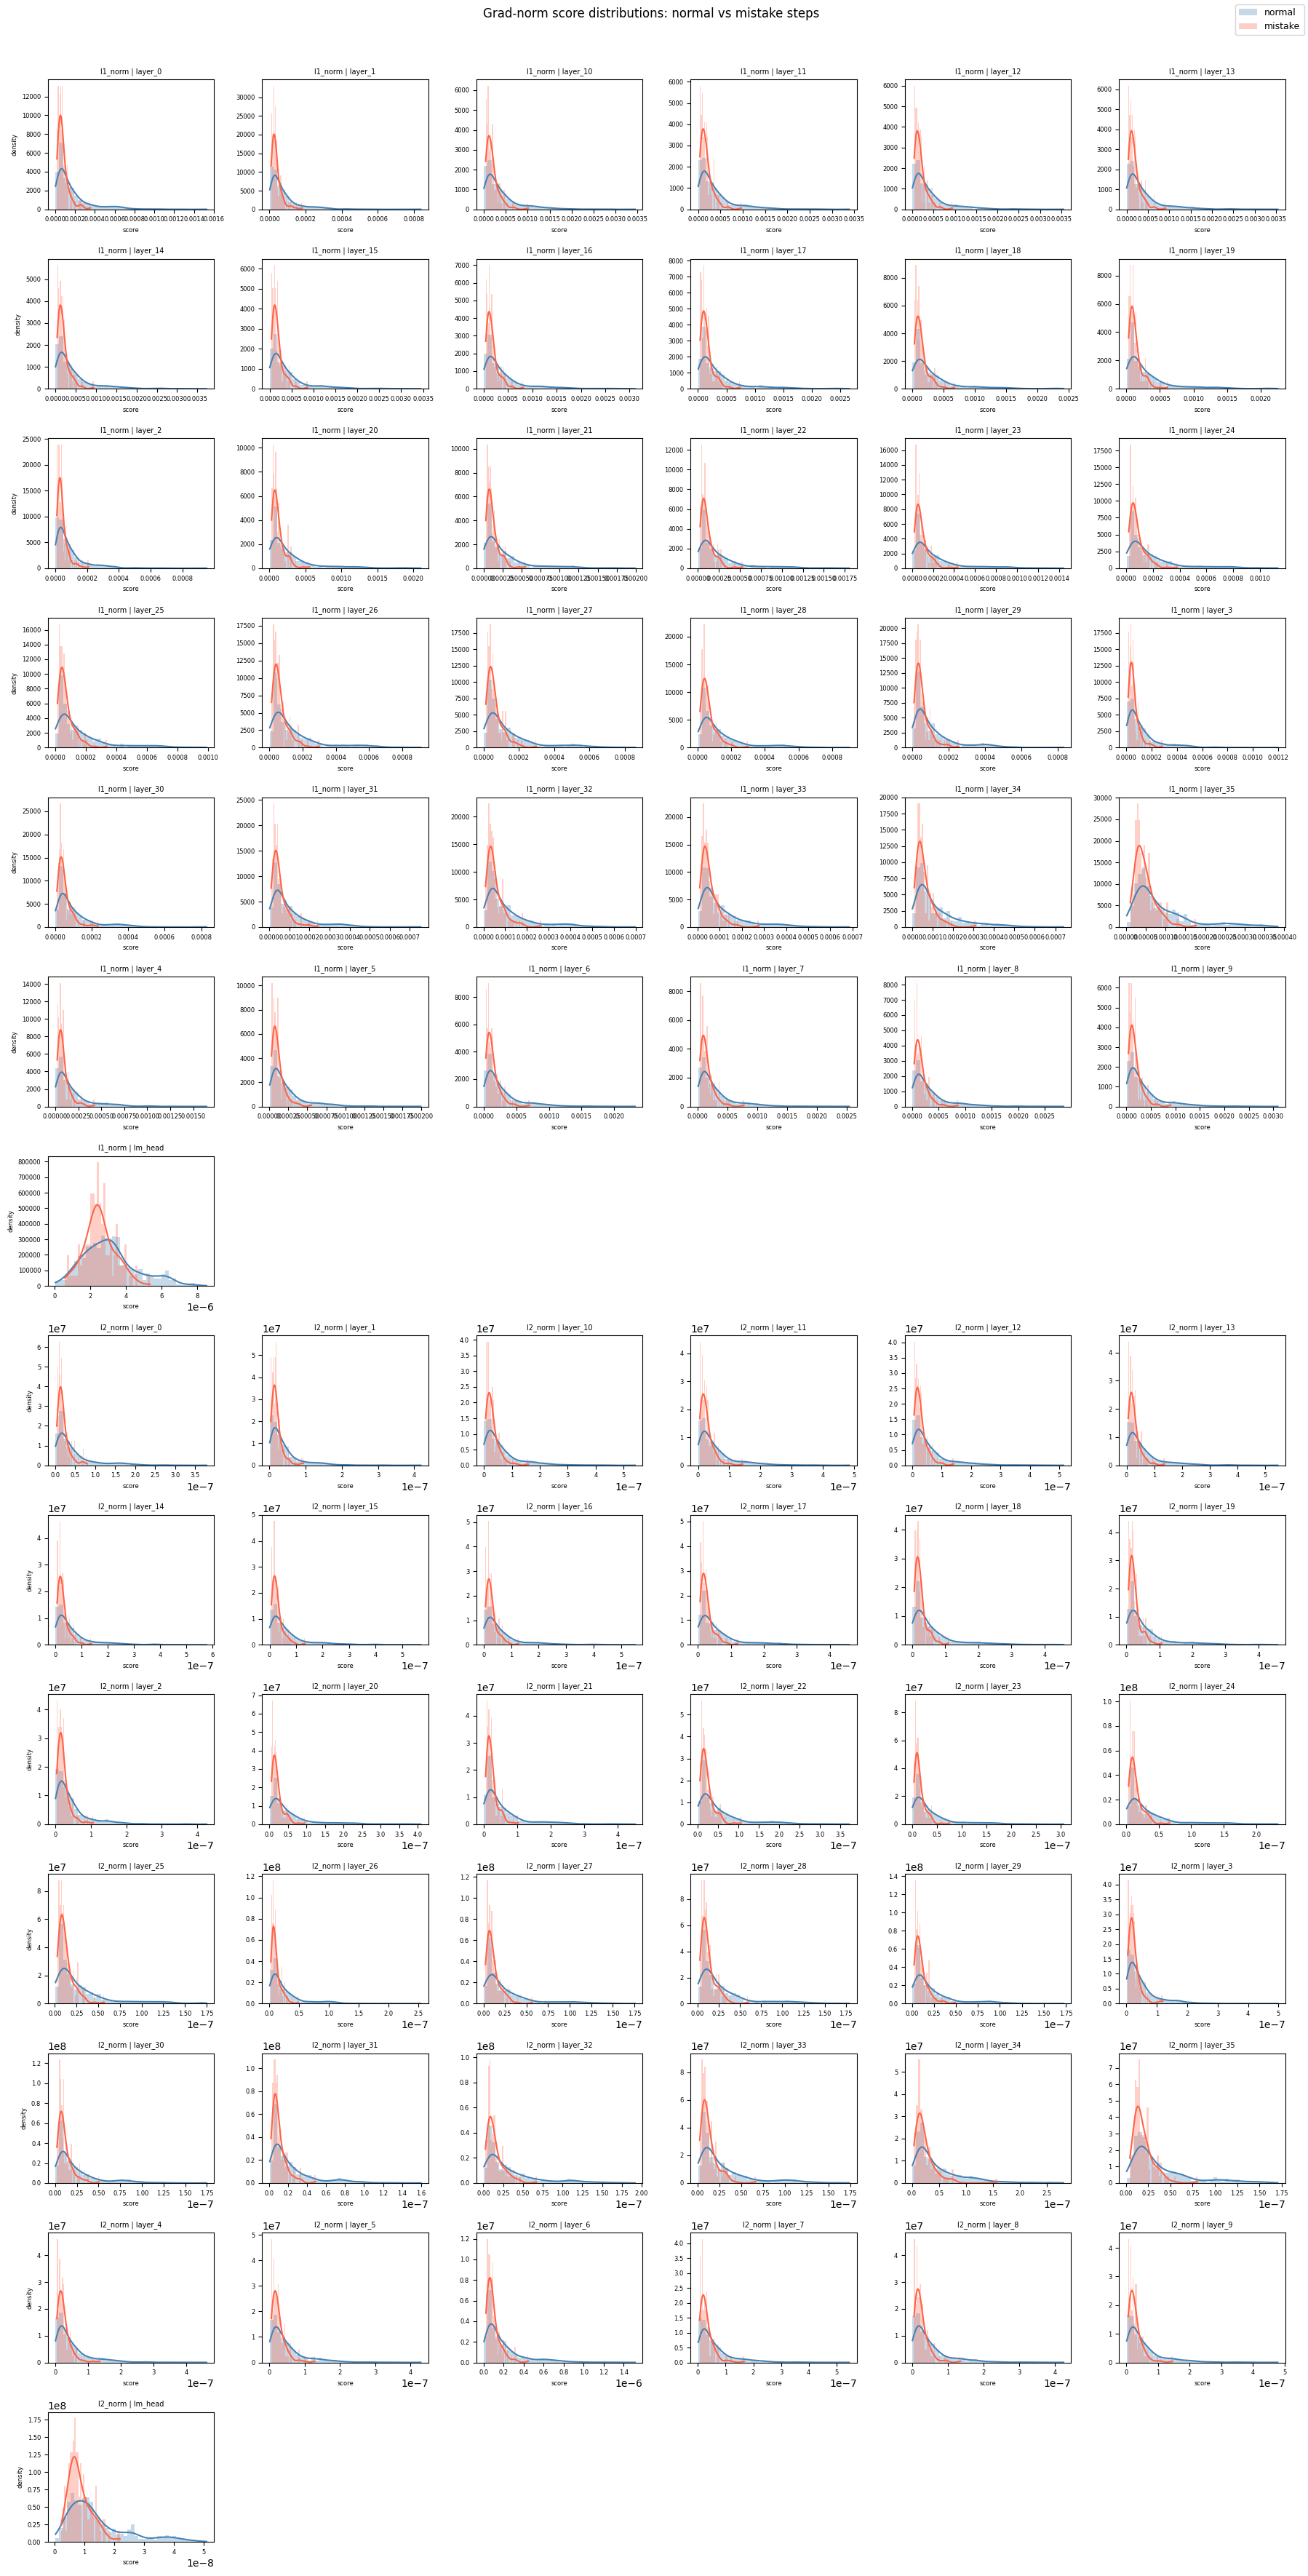

In [4]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from scipy.stats import gaussian_kde

# ── config ────────────────────────────────────────────────────────────────────
RESULTS_DIR = Path("outputs/qwen3-8b/grad-norm/algorithm-generated")
NORM_TYPES   = ["l1_norm", "l2_norm"]
NCOLS        = 6
ALPHA        = 0.3
BINS         = 40

# ── collect scores ────────────────────────────────────────────────────────────
scores = {nt: defaultdict(lambda: {"mistake": [], "normal": []}) for nt in NORM_TYPES}

for fpath in sorted(RESULTS_DIR.glob("*.json")):
    data         = json.loads(fpath.read_text())
    mistake_step = int(data["metadata"]["mistake_step"])

    for log in data["logs"]:
        step = int(log["step_idx"])
        kind = "mistake" if step == mistake_step else "normal"
        for nt in NORM_TYPES:
            for layer, val in log[nt].items():
                scores[nt][layer][kind].append(val)

# ── plot ──────────────────────────────────────────────────────────────────────
layers = sorted(scores[NORM_TYPES[0]].keys(), key=lambda x: (x == "lm_head", x))
n_layers = len(layers)
n_rows_per_norm = (n_layers + NCOLS - 1) // NCOLS

fig, axes = plt.subplots(
    nrows = len(NORM_TYPES) * n_rows_per_norm,
    ncols = NCOLS,
    figsize = (NCOLS * 3, len(NORM_TYPES) * n_rows_per_norm * 2.5),
)
axes = np.array(axes).reshape(len(NORM_TYPES), n_rows_per_norm, NCOLS)

def plot_hist_kde(ax, vals, label, color):
    if len(vals) < 2:
        return
    arr = np.array(vals)
    ax.hist(arr, bins=BINS, alpha=ALPHA, density=True, color=color, label=label)
    xs  = np.linspace(arr.min(), arr.max(), 300)
    ax.plot(xs, gaussian_kde(arr)(xs), color=color, linewidth=1.5)

for ni, nt in enumerate(NORM_TYPES):
    for li, layer in enumerate(layers):
        row, col = divmod(li, NCOLS)
        ax = axes[ni, row, col]
        plot_hist_kde(ax, scores[nt][layer]["normal"],  "normal",  "steelblue")
        plot_hist_kde(ax, scores[nt][layer]["mistake"], "mistake", "tomato")
        ax.set_title(f"{nt} | {layer}", fontsize=7)
        ax.tick_params(labelsize=6)
        ax.set_xlabel("score", fontsize=6)
        if col == 0:
            ax.set_ylabel("density", fontsize=6)

    for li in range(n_layers, n_rows_per_norm * NCOLS):
        row, col = divmod(li, NCOLS)
        axes[ni, row, col].set_visible(False)

handles, labels = axes[0, 0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", fontsize=9)
fig.suptitle("Grad-norm score distributions: normal vs mistake steps", y=1.01)
plt.tight_layout()
plt.show()

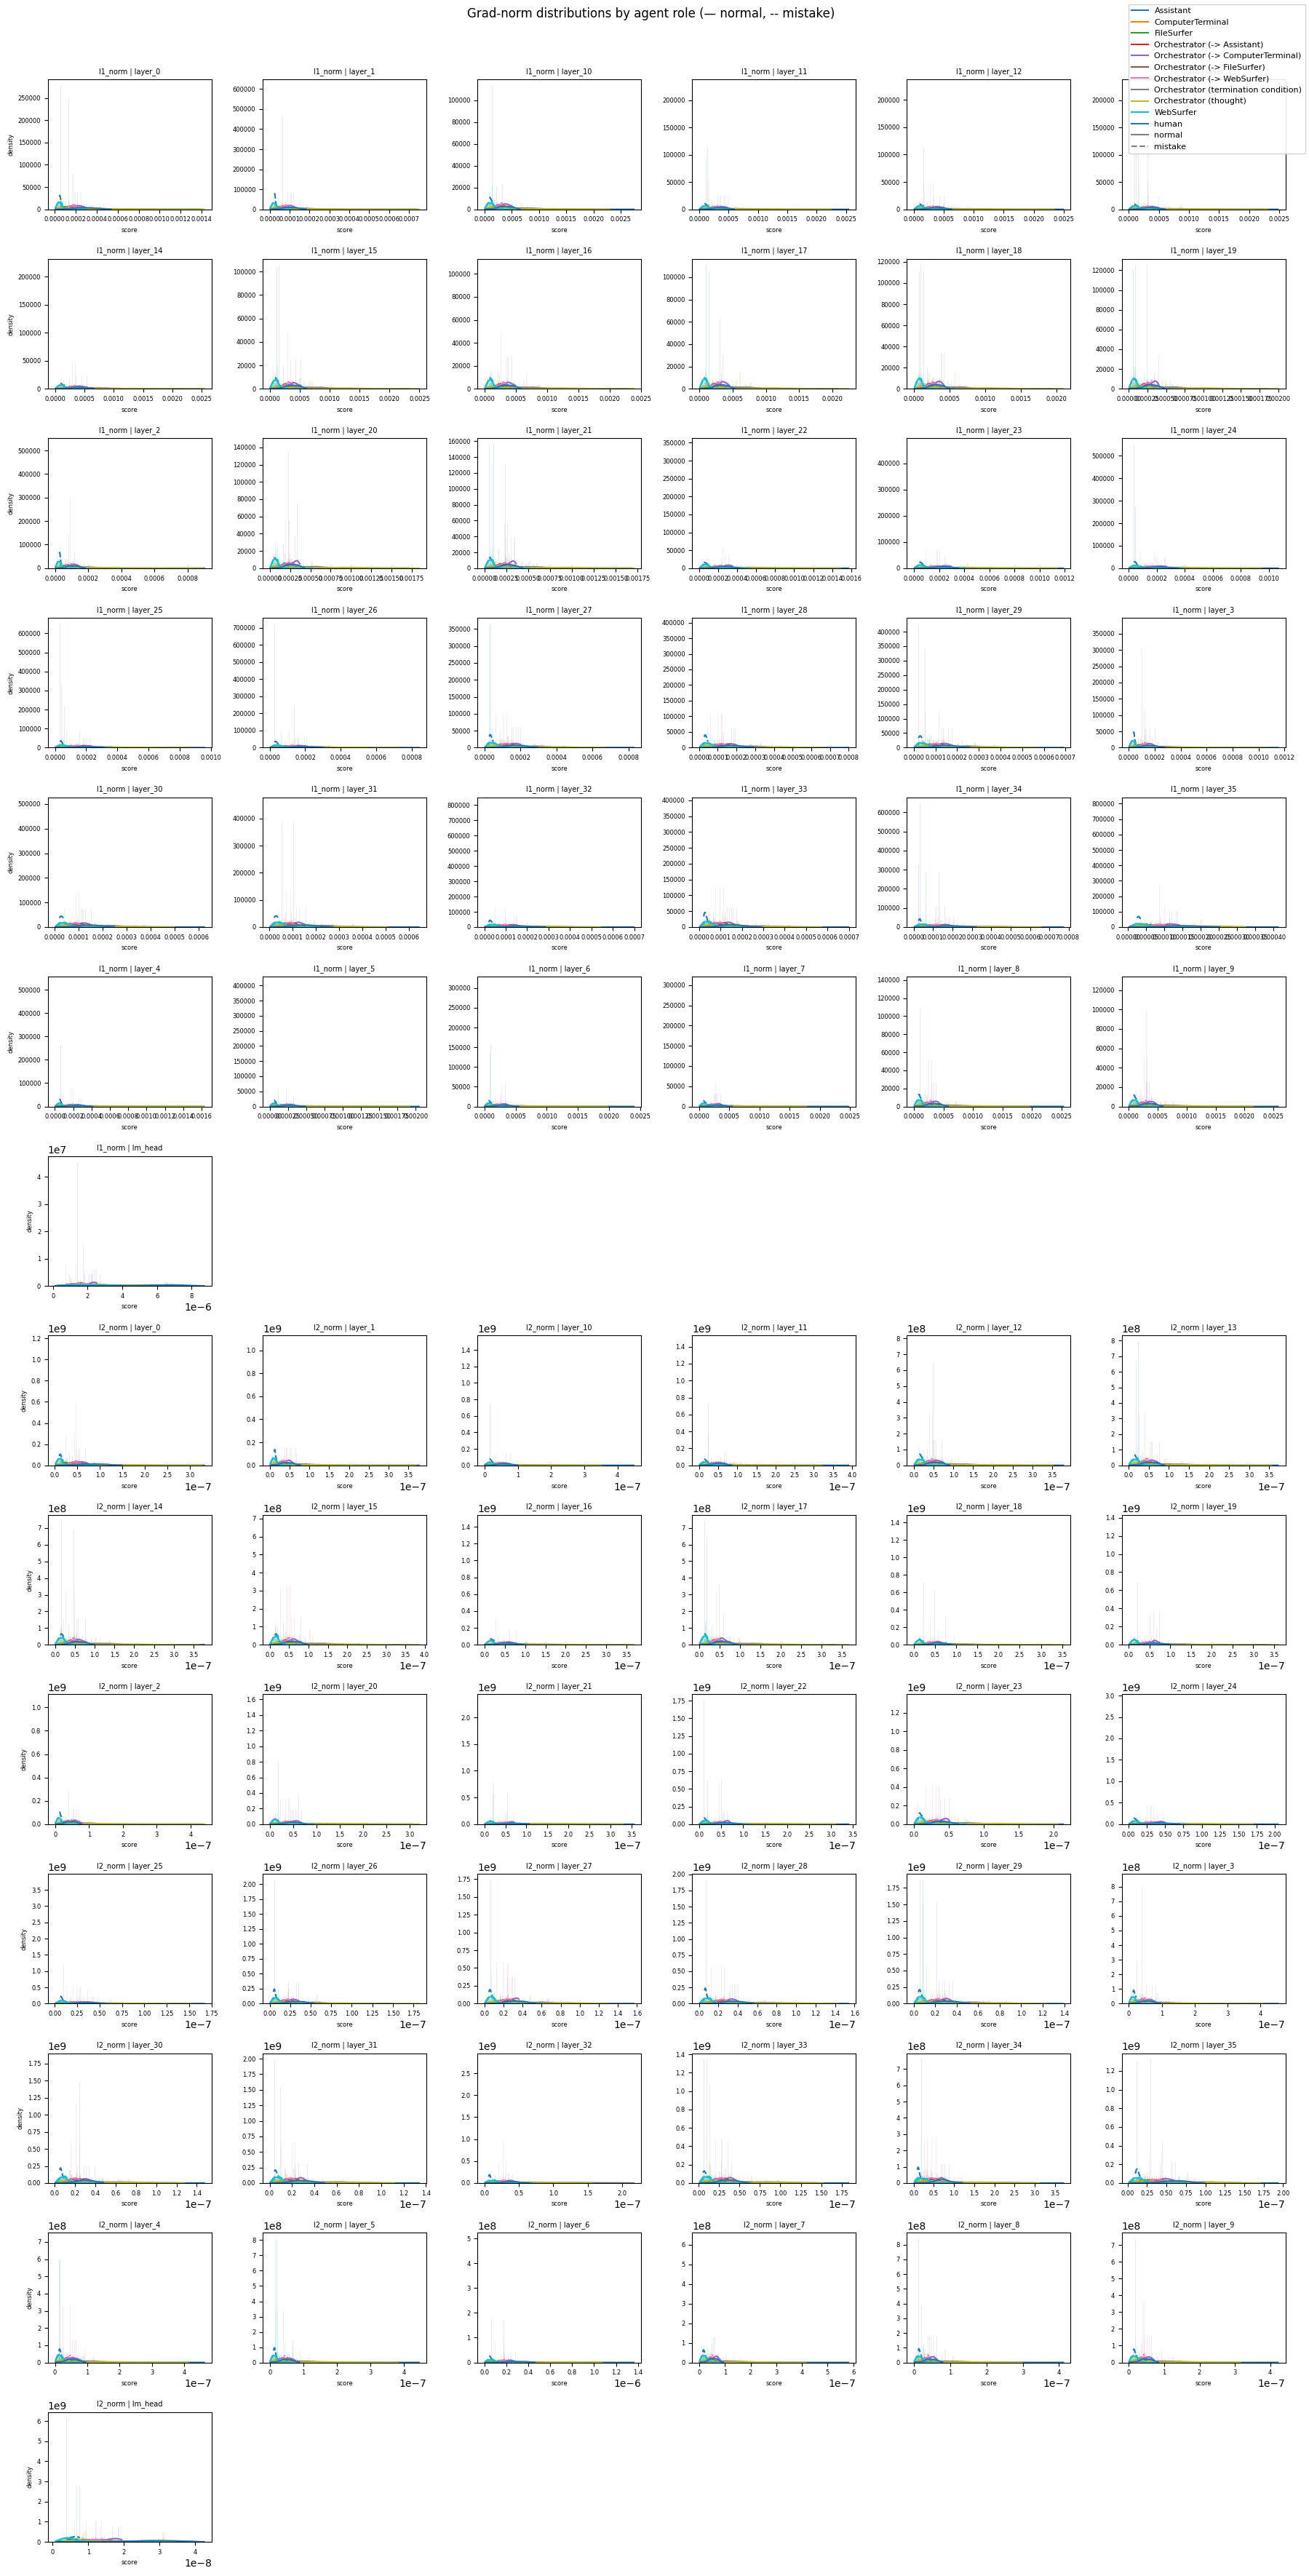

In [5]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from scipy.stats import gaussian_kde

# ── config ────────────────────────────────────────────────────────────────────
RESULTS_DIR = Path("outputs/qwen3-8b/grad-norm/hand-crafted")
NORM_TYPES   = ["l1_norm", "l2_norm"]
NCOLS        = 6
ALPHA        = 0.15
BINS         = 40

# ── collect scores ────────────────────────────────────────────────────────────
# scores[norm_type][layer][role][kind] = [val, ...]
scores = {nt: defaultdict(lambda: defaultdict(lambda: {"mistake": [], "normal": []}))
          for nt in NORM_TYPES}

for fpath in sorted(RESULTS_DIR.glob("*.json")):
    data         = json.loads(fpath.read_text())
    mistake_step = int(data["metadata"]["mistake_step"])
    step_to_role = {s["step_idx"]: s["role"] for s in data["steps"]}

    for log in data["logs"]:
        step = int(log["step_idx"])
        kind = "mistake" if step == mistake_step else "normal"
        role = step_to_role.get(step, "unknown")
        for nt in NORM_TYPES:
            for layer, val in log[nt].items():
                scores[nt][layer][role][kind].append(val)

# ── plot ──────────────────────────────────────────────────────────────────────
layers   = sorted(scores[NORM_TYPES[0]].keys(), key=lambda x: (x == "lm_head", x))
all_roles = sorted({role for nt in NORM_TYPES
                         for layer in layers
                         for role in scores[nt][layer]})
palette  = plt.cm.tab10.colors
role_color = {role: palette[i % len(palette)] for i, role in enumerate(all_roles)}

n_layers       = len(layers)
n_rows_per_norm = (n_layers + NCOLS - 1) // NCOLS

fig, axes = plt.subplots(
    nrows = len(NORM_TYPES) * n_rows_per_norm,
    ncols = NCOLS,
    figsize = (NCOLS * 3, len(NORM_TYPES) * n_rows_per_norm * 2.5),
)
axes = np.array(axes).reshape(len(NORM_TYPES), n_rows_per_norm, NCOLS)

def plot_kde(ax, vals, label, color, linestyle):
    if len(vals) < 2:
        return
    arr = np.array(vals)
    ax.hist(arr, bins=BINS, alpha=ALPHA, density=True, color=color)
    xs  = np.linspace(arr.min(), arr.max(), 300)
    ax.plot(xs, gaussian_kde(arr)(xs), color=color, linewidth=1.5,
            linestyle=linestyle, label=label)

for ni, nt in enumerate(NORM_TYPES):
    for li, layer in enumerate(layers):
        row, col = divmod(li, NCOLS)
        ax = axes[ni, row, col]
        for role in all_roles:
            c = role_color[role]
            plot_kde(ax, scores[nt][layer][role]["normal"],  f"{role} normal",  c, "-")
            plot_kde(ax, scores[nt][layer][role]["mistake"], f"{role} mistake", c, "--")
        ax.set_title(f"{nt} | {layer}", fontsize=7)
        ax.tick_params(labelsize=6)
        ax.set_xlabel("score", fontsize=6)
        if col == 0:
            ax.set_ylabel("density", fontsize=6)

    for li in range(n_layers, n_rows_per_norm * NCOLS):
        row, col = divmod(li, NCOLS)
        axes[ni, row, col].set_visible(False)

# legend: one entry per role (color) + linestyle guide for normal/mistake
legend_elements = [
    plt.Line2D([0], [0], color=role_color[r], linewidth=1.5, label=r)
    for r in all_roles
] + [
    plt.Line2D([0], [0], color="gray", linewidth=1.5, linestyle="-",  label="normal"),
    plt.Line2D([0], [0], color="gray", linewidth=1.5, linestyle="--", label="mistake"),
]
fig.legend(handles=legend_elements, loc="upper right", fontsize=8, framealpha=0.9)
fig.suptitle("Grad-norm distributions by agent role (— normal, -- mistake)", y=1.01)
plt.tight_layout()
plt.show()